# **Bar Charts**


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 190.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 151.4 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")
df.head()

--2026-02-05 10:01:39--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  45.7MB/s    in 3.5s    

2026-02-05 10:01:42 (43.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [3]:
# Drop missing values
comp_data = df['ConvertedCompYearly'].dropna()

# Optional: filter out extreme outliers (e.g., > 500,000)
comp_data = comp_data[comp_data < 500000]

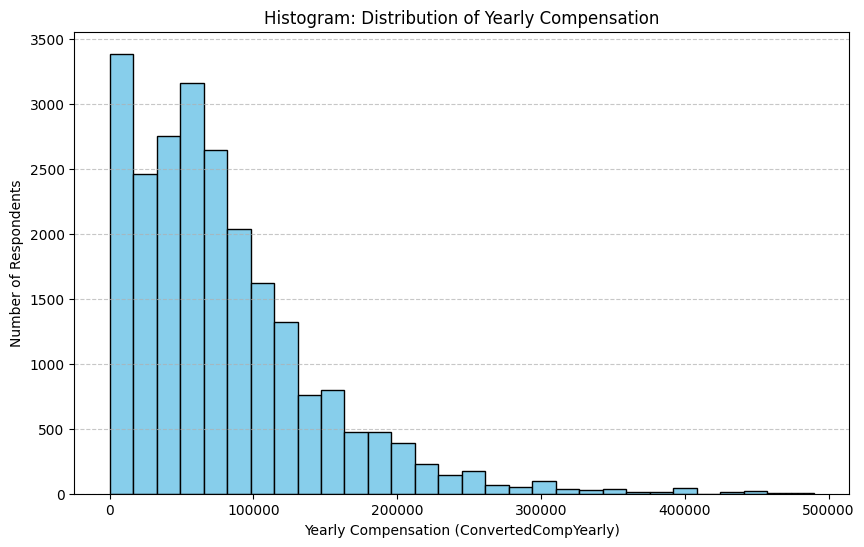

In [4]:
plt.figure(figsize=(10,6))

plt.hist(comp_data, bins=30, color='skyblue', edgecolor='black')

plt.title("Histogram: Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Number of Respondents")
plt.grid(axis='y', linestyle='--', alpha=0.7)

##### Insights: 
- You’ll likely see a right-skewed distribution (many respondents in lower/mid ranges, fewer in very high ranges).
- The histogram helps identify common salary bands and outliers.
- Filtering extreme outliers makes the visualization more interpretable.

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [5]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

# Convert categorical Age to numeric midpoints
df['Age_numeric'] = df['Age'].map(age_map)

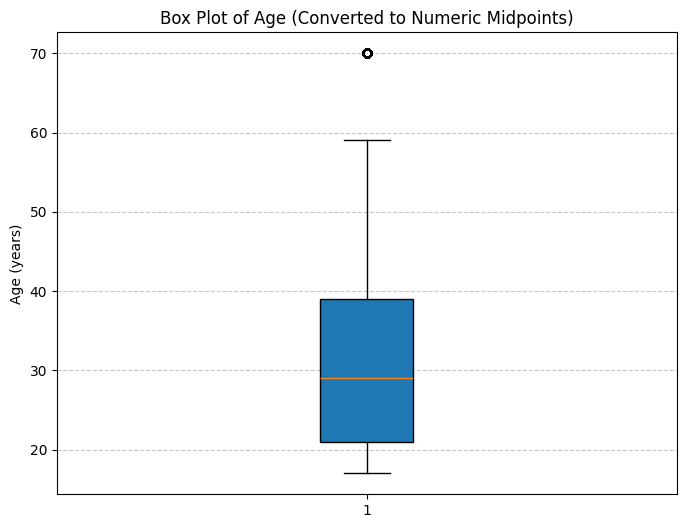

In [6]:
plt.figure(figsize=(8,6))

plt.boxplot(df['Age_numeric'].dropna(), vert=True, patch_artist=True)

plt.title("Box Plot of Age (Converted to Numeric Midpoints)")
plt.ylabel("Age (years)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



In [7]:
# Count frequency of each primary role
mainbranch_counts = df['MainBranch'].value_counts().reset_index()
mainbranch_counts.columns = ['MainBranch', 'Count']

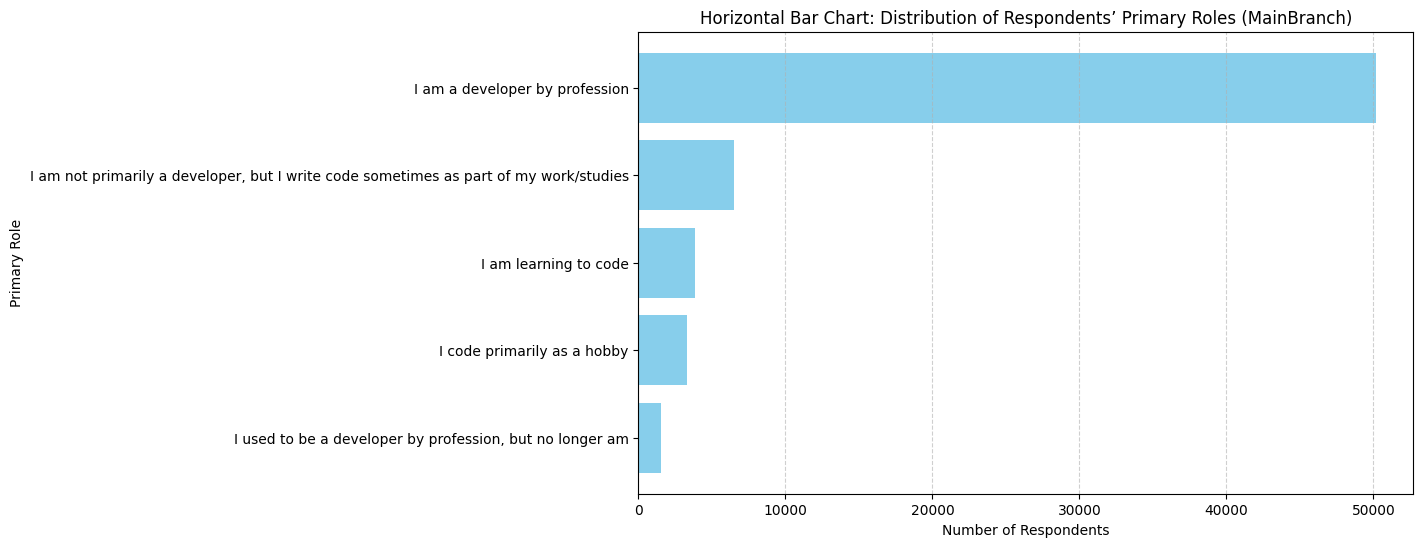

In [8]:
plt.figure(figsize=(10,6))

plt.barh(mainbranch_counts['MainBranch'], mainbranch_counts['Count'], color='skyblue')

plt.title("Horizontal Bar Chart: Distribution of Respondents’ Primary Roles (MainBranch)")
plt.xlabel("Number of Respondents")
plt.ylabel("Primary Role")
plt.gca().invert_yaxis()  # Highest count at the top
plt.grid(axis='x', linestyle='--', alpha=0.6)

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



In [9]:
# Split multiple languages into separate rows
df_langs = df.assign(LanguageWantToWorkWith=df['LanguageWantToWorkWith'].str.split(';')).explode('LanguageWantToWorkWith')
df_langs['LanguageWantToWorkWith'] = df_langs['LanguageWantToWorkWith'].str.strip()

In [10]:
# Count frequency of each language
lang_counts = df_langs['LanguageWantToWorkWith'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Count']

# Select top 5 languages
top5_langs = lang_counts.head(5)

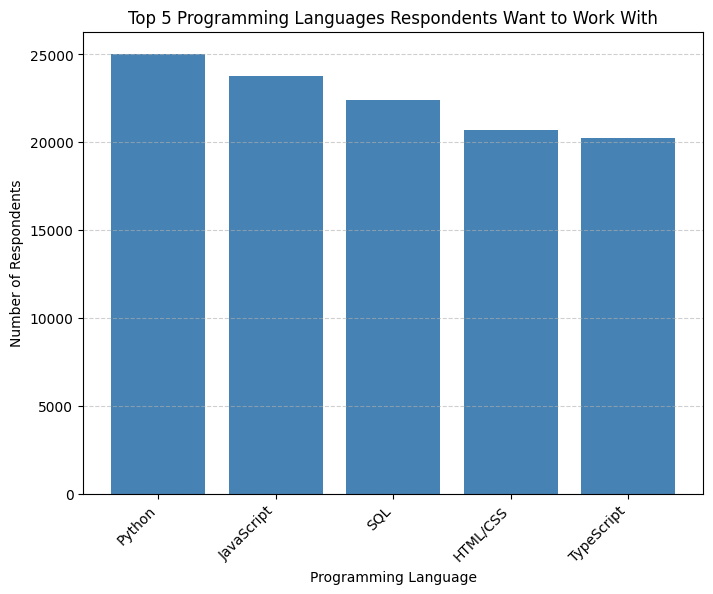

In [11]:
plt.figure(figsize=(8,6))

plt.bar(top5_langs['Language'], top5_langs['Count'], color='steelblue')

plt.title("Top 5 Programming Languages Respondents Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


In [12]:
age_map = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}
df['AgeGroup'] = df['Age'].map(age_map)

In [13]:
job_sat_summary = df.groupby('AgeGroup').agg(
    MedianJobSat6=('JobSatPoints_6', 'median'),
    MedianJobSat7=('JobSatPoints_7', 'median')
).reset_index()

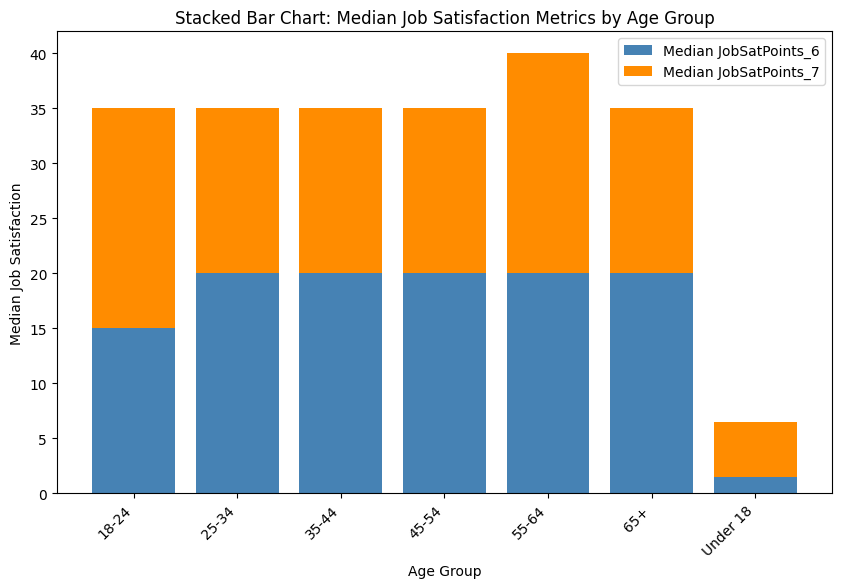

In [14]:
plt.figure(figsize=(10,6))

# Plot JobSatPoints_6
plt.bar(job_sat_summary['AgeGroup'], 
        job_sat_summary['MedianJobSat6'], 
        label='Median JobSatPoints_6', color='steelblue')

# Stack JobSatPoints_7 above JobSatPoints_6
plt.bar(job_sat_summary['AgeGroup'], 
        job_sat_summary['MedianJobSat7'], 
        bottom=job_sat_summary['MedianJobSat6'], 
        label='Median JobSatPoints_7', color='darkorange')

plt.title("Stacked Bar Chart: Median Job Satisfaction Metrics by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



In [15]:
# Split multiple databases into separate rows
df_db = df.assign(DatabaseHaveWorkedWith=df['DatabaseHaveWorkedWith'].str.split(';')).explode('DatabaseHaveWorkedWith')
df_db['DatabaseHaveWorkedWith'] = df_db['DatabaseHaveWorkedWith'].str.strip()

In [16]:
# Count frequency of each database
db_counts = df_db['DatabaseHaveWorkedWith'].value_counts().reset_index()
db_counts.columns = ['Database', 'Count']

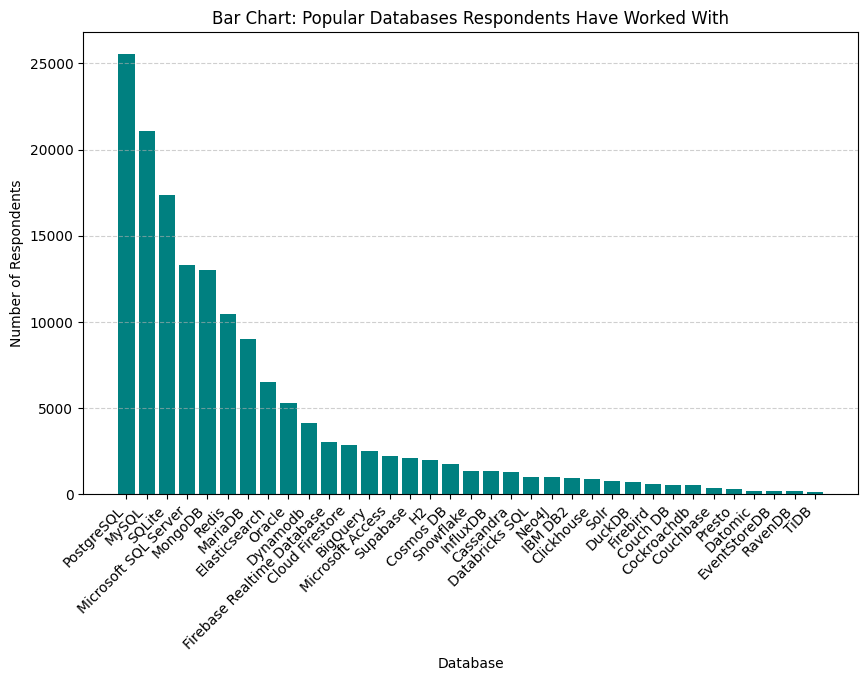

In [17]:
plt.figure(figsize=(10,6))

plt.bar(db_counts['Database'], db_counts['Count'], color='teal')

plt.title("Bar Chart: Popular Databases Respondents Have Worked With")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)

##### Insights:
- MySQL and PostgreSQL often dominate due to their widespread use in web and enterprise applications.
- MongoDB is popular among younger developers and startups for NoSQL projects.
- SQL Server and Oracle remain strong in enterprise environments.

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [18]:
comp_summary = df.groupby('AgeGroup')['ConvertedCompYearly'].median().reset_index()

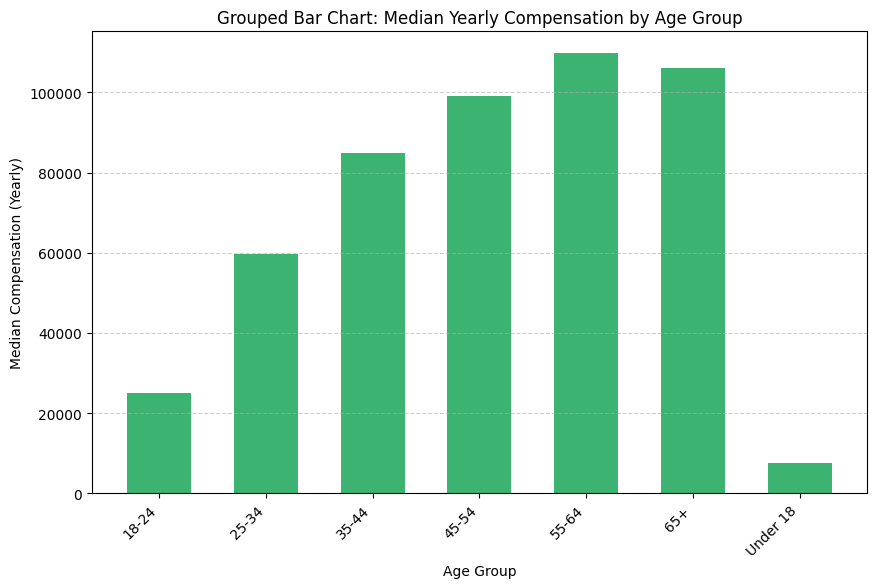

In [19]:
plt.figure(figsize=(10,6))

plt.bar(comp_summary['AgeGroup'], comp_summary['ConvertedCompYearly'], 
        color='mediumseagreen', width=0.6)

plt.title("Grouped Bar Chart: Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Compensation (Yearly)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [20]:
# Count frequency of each country
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

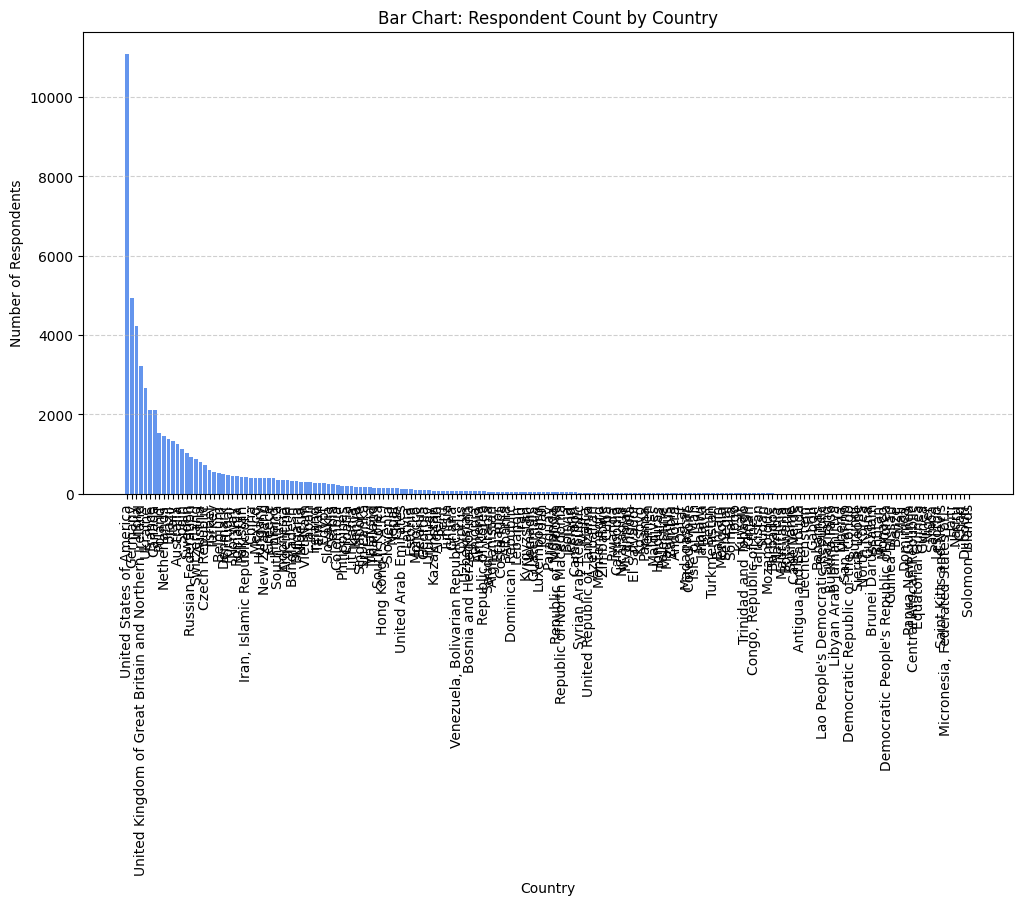

In [21]:
plt.figure(figsize=(12,6))

plt.bar(country_counts['Country'], country_counts['Count'], color='cornflowerblue')

plt.title("Bar Chart: Respondent Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)

## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain
